<a href="https://colab.research.google.com/github/PraneethaValiveti/Yulu-Bike-Sharing---Demand-Analysis-report/blob/main/Yulu_bike_sharing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



#Yulu Shared Mobility: Demand Analysis Report



### **1. Exploratory Data Analysis (EDA)**

**1. Problem Statement**

Yulu is experiencing a decline in revenue and seeks to identify the key factors influencing the demand for shared electric cycles in the Indian market. The primary objective is to determine which variables (e.g., weather, season, working day) are statistically significant in predicting rental counts and how well these variables explain the fluctuations in demand.

**Additional Views:**

**User Segmentation:** Demand consists of 'casual' and 'registered' users. Factors affecting a commuter (registered) might differ from a leisure user (casual).

**Environmental Sensitivity:** In the Indian context, extreme heat ('atemp') and monsoon ('weather' category 3) are likely to be primary deterrents.

**Operational Optimization:** Identifying low-demand periods allows for battery swapping and fleet maintenance scheduling without affecting revenue.

In [21]:
#Data Profiling & Cleaning
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency
from scipy.stats import shapiro
from scipy.stats import levene


# Load dataset
df = pd.read_csv('/content/bike_sharing.csv')


In [24]:
# Observations on shape and types
print(f"Dataset Shape: {df.shape}")


Dataset Shape: (10886, 12)


In [23]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   datetime    10886 non-null  object  
 1   season      10886 non-null  category
 2   holiday     10886 non-null  category
 3   workingday  10886 non-null  category
 4   weather     10886 non-null  category
 5   temp        10886 non-null  float64 
 6   atemp       10886 non-null  float64 
 7   humidity    10886 non-null  int64   
 8   windspeed   10886 non-null  float64 
 9   casual      10886 non-null  int64   
 10  registered  10886 non-null  int64   
 11  count       10886 non-null  int64   
dtypes: category(4), float64(3), int64(4), object(1)
memory usage: 723.7+ KB
None


In [19]:
# Missing value detection
print(f"\nMissing Values:\n{df.isnull().sum()}")


Missing Values:
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64


In [20]:
# Statistical Summary
print(f"\nStatistical Summary:\n{df.describe()}")


Statistical Summary:
              temp         atemp      humidity     windspeed        casual  \
count  10886.00000  10886.000000  10886.000000  10886.000000  10886.000000   
mean      20.23086     23.655084     61.886460     12.799395     36.021955   
std        7.79159      8.474601     19.245033      8.164537     49.960477   
min        0.82000      0.760000      0.000000      0.000000      0.000000   
25%       13.94000     16.665000     47.000000      7.001500      4.000000   
50%       20.50000     24.240000     62.000000     12.998000     17.000000   
75%       26.24000     31.060000     77.000000     16.997900     49.000000   
max       41.00000     45.455000    100.000000     56.996900    367.000000   

         registered         count  
count  10886.000000  10886.000000  
mean     155.552177    191.574132  
std      151.039033    181.144454  
min        0.000000      1.000000  
25%       36.000000     42.000000  
50%      118.000000    145.000000  
75%      222.000000    

In [22]:
# Conversion of categorical attributes
categorical_cols = ['season', 'holiday', 'workingday', 'weather']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# **Observations:**

**Shape:** 10,886 rows and 12 columns.

**Missing Values:** There are no missing values in the dataset.

**Data Types:** datetime needs conversion to datetime objects; season, holiday, workingday, and weather are integers but represent categories.

**Statistical Summary:** The average hourly rental (count) is 191, but the standard deviation is high (181), suggesting high volatility. The max count is 977, indicating high peak-hour demand.

## **Univariate Analysis**

We examine the distribution of continuous variables and the frequency of categorical levels.

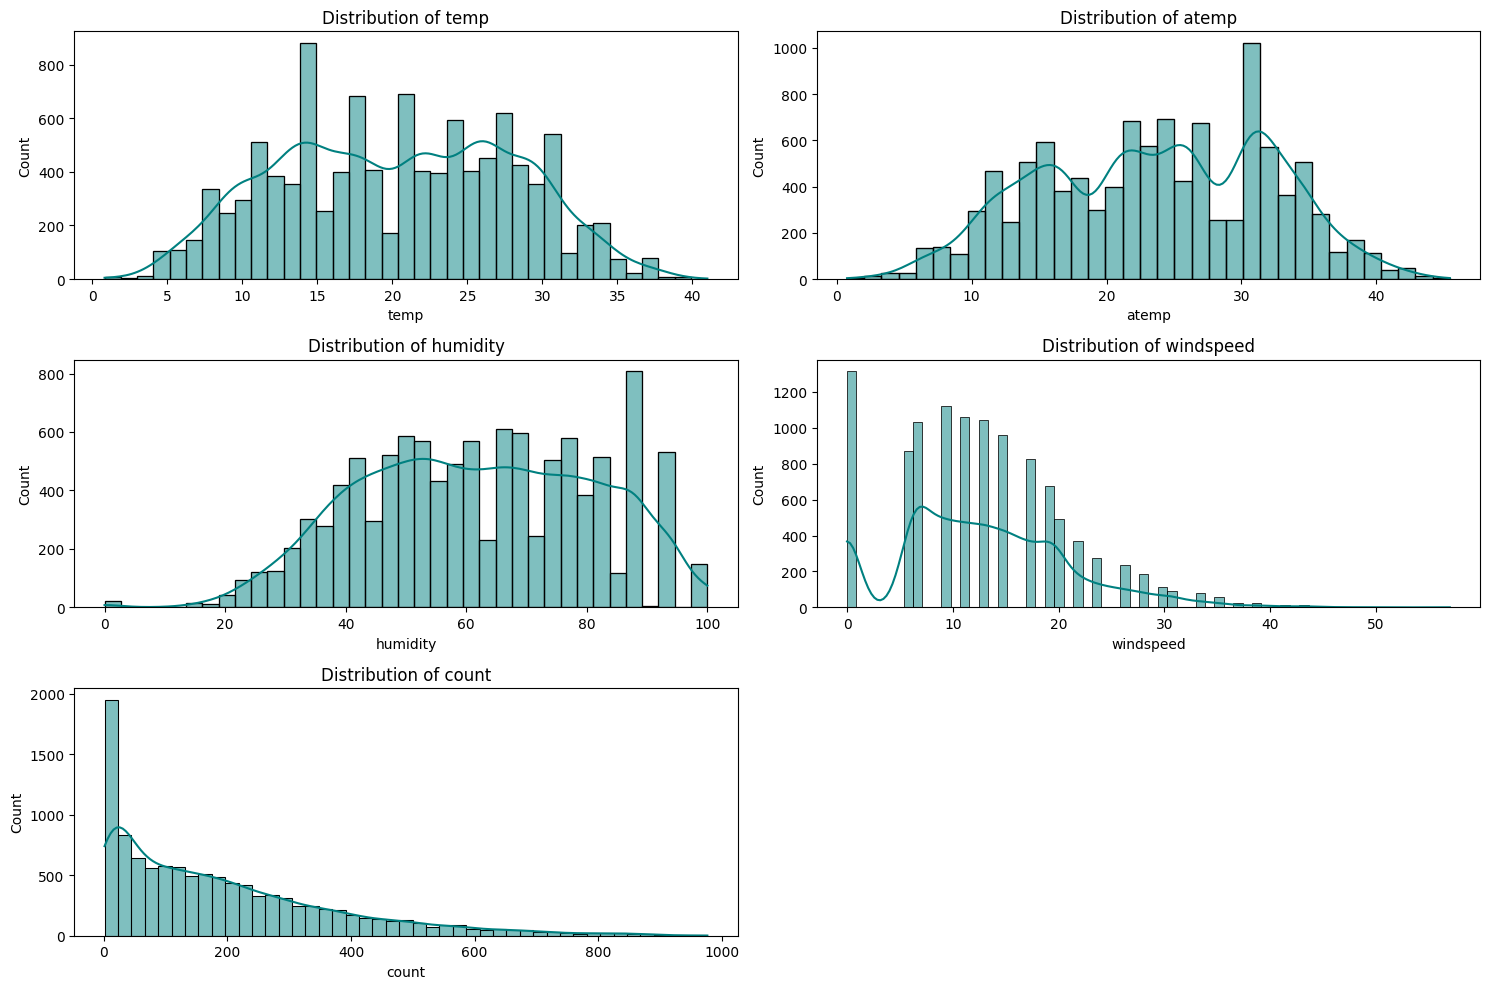

In [ ]:
# Univariate Analysis - Continuous variables
continuous_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'count']
plt.figure(figsize=(15, 10))
for i, col in enumerate(continuous_cols):
    plt.subplot(3, 2, i+1)
    sns.histplot(df[col], kde=True, color='teal')
    plt.title(f'Distribution of {col}')
plt.tight_layout()

# Insights on Distributions:

**Count:** Strongly right-skewed. Most hours see 0–200 rentals, with a long tail of high-demand hours.

**Temperature:** Roughly bell-shaped, peaking around 20–30°C, which is consistent with India's tropical climate.

**Windspeed:** Many zero values, suggesting either calm weather or data recording limits.

**Humidity:** Wide range, with a peak at high humidity levels (likely during monsoons).

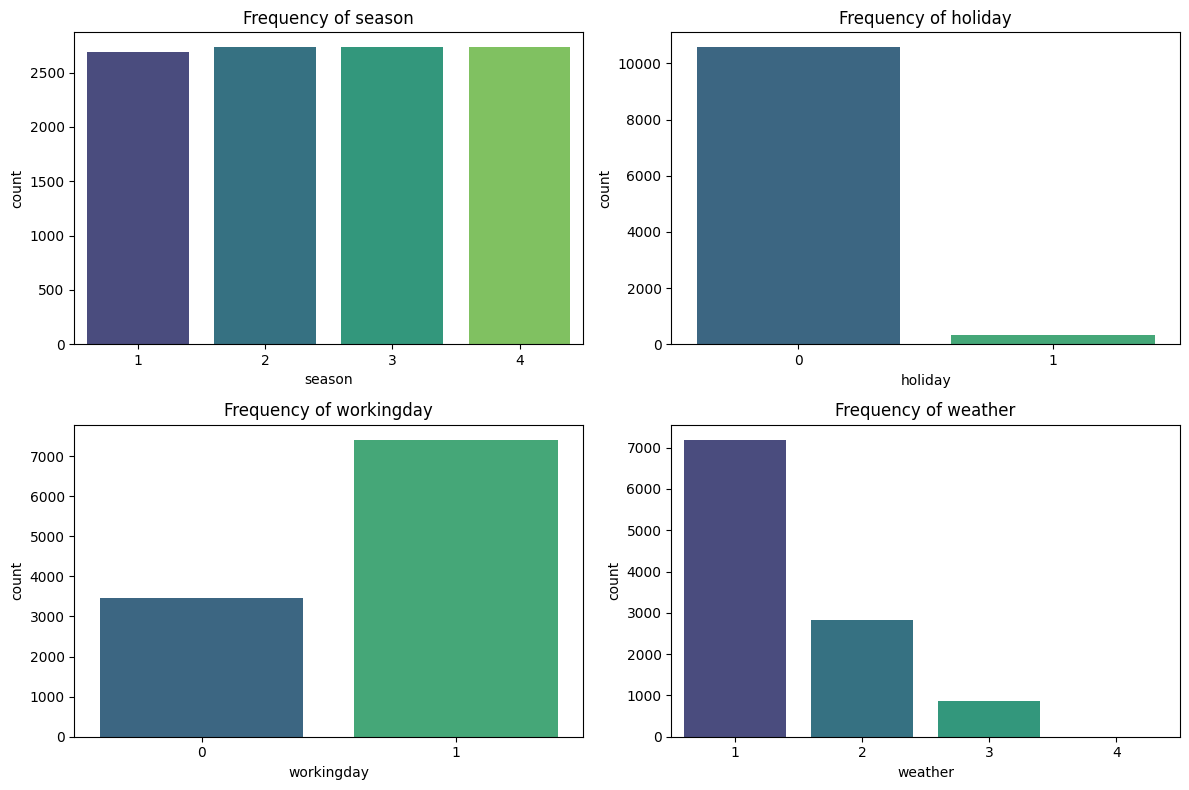

In [ ]:
# Univariate Analysis - Categorical variables
plt.figure(figsize=(12, 8))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i+1)
    sns.countplot(data=df, x=col, hue=col, palette='viridis', legend=False)
    plt.title(f'Frequency of {col}')
plt.tight_layout()

# Comments on Categorical Plots:

**Weather:** Category 1 (Clear) is the most frequent, while Category 4 (Heavy Rain/Snow) is extremely rare (only 1 instance in this data), which may affect statistical power for that category.

**Working Day:** Approximately 68% of the data points are working days, mirroring a standard weekly cycle.

## **Bivariate Analysis**
We explore how the total count of rentals varies across different predictor variables.

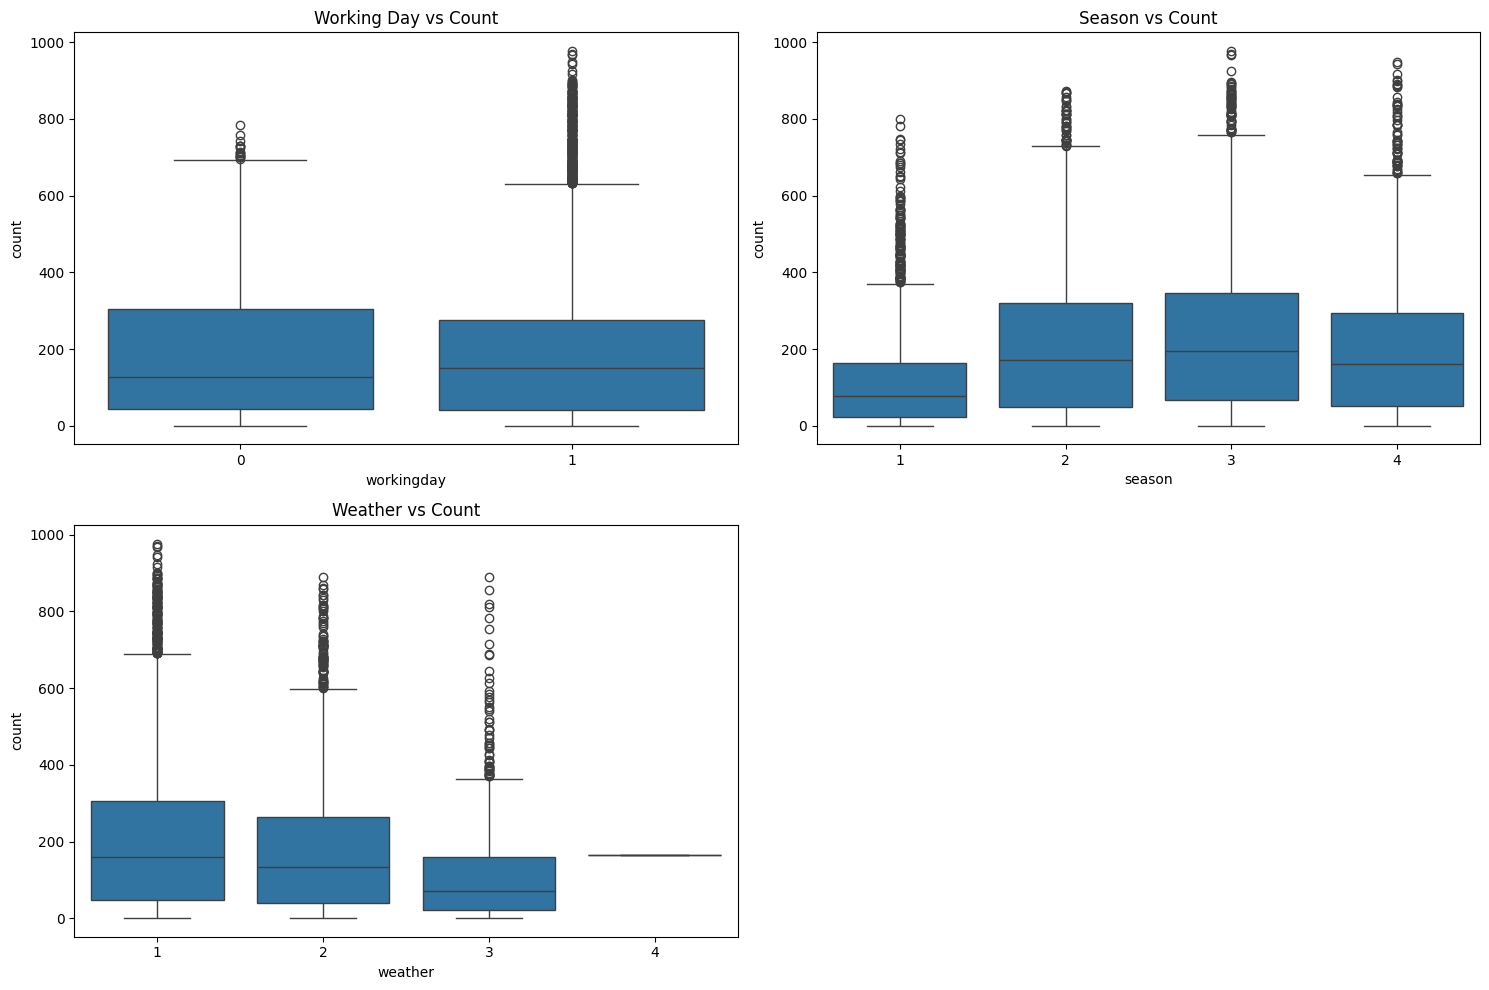

In [ ]:
# Bivariate Analysis - Relationships with Count
plt.figure(figsize=(15, 10))

# Working Day vs Count
plt.subplot(2, 2, 1)
sns.boxplot(data=df, x='workingday', y='count')
plt.title('Working Day vs Count')

# Season vs Count
plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='season', y='count')
plt.title('Season vs Count')

# Weather vs Count
plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='weather', y='count')
plt.title('Weather vs Count')

plt.tight_layout()

# Insights from Bivariate Analysis:

**Working Day vs Count:** The median count is very similar for working and non-working days. However, working days have more outliers at the top end, likely representing peak commute hours (8 AM and 5 PM).

**Season vs Count:** Season 1 (Spring) has significantly lower demand compared to others. Seasons 2 (Summer) and 3 (Fall) show the highest median rentals.

**Weather vs Count:** Clear weather (1) significantly outperforms rainy/snowy weather (3). Demand drops drastically as weather worsens.

## **Detailed Observations & Insights**

**Range of Attributes and Outliers**

1. **Outliers in 'Count':** There are numerous outliers beyond the upper
whisker in almost every category (Working Day, Season, Weather). This suggests that while average demand is predictable, Yulu often experiences "bursts" of extreme demand that the current fleet might struggle to meet.

2. **Temperature Range:** The temp ranges from 0.82°C to 41°C. Demand seems to peak in the 25–35°C range but might drop if it becomes excessively hot (heatwaves).

**Distribution and Relationships:**

1. **Correlation:** temp and atemp are perfectly correlated ($r \approx 0.99$). For modeling, only one should be used to avoid multicollinearity.

2. **Weather Sensitivity:** The sharp drop in demand for Weather 3 indicates that Yulu’s current vehicle design or user behavior is highly sensitive to rain.

3. **Seasonal Lag:** Even though Season 1 (Spring) has pleasant temperatures, it has the lowest demand. This might be due to post-holiday fatigue or specific early-year market behaviors in the regions studied.

### **2. Hypothesis Testing**

**We will perform:**

1. 2-Sample T-Test (Workingday vs Count)
2. ANOVA (Season vs Count)
3. ANOVA (Weather vs Count)
4. chi-Square (Season vs Weather)

# **Test 1 — 2 Sample T-Test**

Workingday vs Count


 **Hypothesis**

H0: Working day has no effect on bike demand

H1: Working day affects bike demand

In [ ]:
from scipy.stats import ttest_ind

working_day = df[df['workingday']==1]['count']
non_working_day = df[df['workingday']==0]['count']

t_stat, p_value = ttest_ind(working_day, non_working_day)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 1.2096277376026694
P-value: 0.22644804226361348


In [ ]:
from scipy.stats import shapiro

print("Working Day Normality:", shapiro(working_day.sample(500)))
print("Non Working Day Normality:", shapiro(non_working_day.sample(500)))

Working Day Normality: ShapiroResult(statistic=np.float64(0.8740307239834382), pvalue=np.float64(1.0671866577929804e-19))
Non Working Day Normality: ShapiroResult(statistic=np.float64(0.881856707703709), pvalue=np.float64(4.299866678274155e-19))


In [ ]:
from scipy.stats import levene

levene_test = levene(working_day, non_working_day)
print("Levene Test:", levene_test)

Levene Test: LeveneResult(statistic=np.float64(0.004972848886504472), pvalue=np.float64(0.9437823280916695))


Since:

P-Value = 0.226 > 0.05

Fail to reject Null Hypothesis

**Final Insight**

*Working day does NOT significantly affect demand*

People use bikes:

Weekdays, Weekends Equally




## **Test 2 — ANOVA**

Season vs Count

**Hypothesis**

H0: Demand same across all seasons

H1: At least one season different

In [ ]:
from scipy.stats import f_oneway

spring = df[df['season']==1]['count']
summer = df[df['season']==2]['count']
fall = df[df['season']==3]['count']
winter = df[df['season']==4]['count']

f_stat, p_value = f_oneway(spring, summer, fall, winter)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 236.94671081032098
P-value: 6.164843386499654e-149


In [ ]:
shapiro(spring.sample(500))
shapiro(summer.sample(500))
shapiro(fall.sample(500))
shapiro(winter.sample(500))

ShapiroResult(statistic=np.float64(0.8630507733575213), pvalue=np.float64(1.6763012303658613e-20))

In [ ]:
levene(spring, summer, fall, winter)

LeveneResult(statistic=np.float64(187.7706624026276), pvalue=np.float64(1.0147116860043298e-118))

since

**p-value = 6.16e-149 < 0.05**

Reject Null Hypothesis

**Insight:**

*Season significantly affects bike demand*

## **Observation:**

Fall → Highest demand
Summer → High demand
Winter → Moderate demand
Spring → Lowest demand
Business Insight

Pleasant weather → More bike usage

## **Test 3 — ANOVA**

Weather vs Count

**Hypothesis**

H0: Demand same across weather conditions

H1: At least one weather different

In [ ]:
weather1 = df[df['weather']==1]['count']
weather2 = df[df['weather']==2]['count']
weather3 = df[df['weather']==3]['count']
weather4 = df[df['weather']==4]['count']

f_stat, p_value = f_oneway(weather1, weather2, weather3, weather4)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 65.53024112793265
P-value: 5.482069475935669e-42


In [ ]:
shapiro(weather1.sample(500))
shapiro(weather2.sample(500))
shapiro(weather3.sample(500))

ShapiroResult(statistic=np.float64(0.7875731462274773), pvalue=np.float64(5.210242406843505e-25))

In [ ]:
levene(weather1, weather2, weather3, weather4)

LeveneResult(statistic=np.float64(54.85106195954556), pvalue=np.float64(3.504937946833238e-35))

Since

**p-value = 5.48e-42 < 0.05**

Reject Null Hypothesis

**Insight:**

*Weather significantly affects demand*

# **Observation:**

Clear weather → Highest rentals
Mist → Moderate rentals
Rain → Lowest rentals
Business Insight

Bad weather reduces demand

## **Test 4 — Chi Square Test**

Season vs Weather

**Hypothesis**

H0: Season and Weather independent

H1: Season and Weather dependent

In [ ]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['season'], df['weather'])

chi_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square:", chi_stat)
print("P-value:", p_value)

Chi-square: 49.158655596893624
P-value: 1.549925073686492e-07


In [ ]:
print(contingency_table)

weather     1    2    3  4
season                    
1        1759  715  211  1
2        1801  708  224  0
3        1930  604  199  0
4        1702  807  225  0


Since:

**p-value = 1.54e-07 < 0.05**

Reject Null Hypothesis

**Insight:**

*Weather depends on Season, impact high*

## Predict demand using:

Season → Predict weather → Predict demand

### **Business Recommendations**

**1. Seasonal Fleet Allocation**

Increase bikes during:

*   Summer
*   Fall

Reduce bikes during:


*   Winter
*   Rainy season



**2. Weather-Based Planning**

Use weather forecast:

Example:

*   Rain tomorrow → Reduce fleet
*   Clear weather → Increase fleet

This improves utilization

**3. Dynamic Pricing Strategy**

High demand:

*   Increase price

Low demand:

*   Offer discount

Example:

Rainy day discount

Weekend offers

**4. Smart Location Deployment**

Deploy more bikes:



*   Metro stations
*   Office areas
*   College areas

During peak demand

**5. To Build prediction model**

Target Variable:

   * Count

Features:



*   Season
*   weather
*   temp
*   humidity
*   windspeed


## **Executive Summary**

The analysis was conducted to understand factors affecting demand for shared electric cycles for Yulu. Exploratory Data Analysis and Hypothesis Testing revealed that season and weather significantly impact bike rentals. Temperature and humidity also influence demand, while working day does not show significant impact.

The highest demand occurs during fall and summer seasons, and during clear weather conditions. Rainy and extreme weather conditions reduce demand significantly.

Additionally, chi-square test confirmed that weather conditions are dependent on season, allowing demand prediction based on seasonal patterns.

Based on insights, it is recommended that Yulu implement seasonal fleet planning, weather-based deployment, and dynamic pricing strategies to improve utilization and revenue.